In [1]:
import pandas as pd
import numpy as np

In [2]:
# Load datasets
df = pd.read_csv('2020_10K_item1_full.csv')
public_firm = pd.read_csv('public_firms.csv')
df_mg = pd.read_csv('major_groups.csv')

In [3]:
df

,cik,year,name,item_1_text,gvkey
0,1041588,2020,ACCESS-POWER INC,fixed expenses are previosuly documented in an...,66119
1,315374,2020,HURCO COMPANIES INC,"General Hurco Companies, Inc. is an internatio...",5788
2,1622996,2020,"ACRO BIOMEDICAL CO., LTD.",We have been engaged in the business of develo...,27584
3,1191334,2020,Chun Can Capital Group,CORPORATE HISTORY Chun Can Capital Group (form...,153614
4,1191334,2020,Chun Can Capital Group,CORPORATE HISTORY Chun Can Capital Group (form...,153614
...,...,...,...,...,...
5476,740664,2020,R F INDUSTRIES LTD,"General RF Industries, Ltd. (together with sub...",2829
5477,1074828,2020,"KNOW LABS, INC.","BACKGROUND AND CAPITAL STRUCTURE Know Labs, In...",166430
5478,40570,2020,GEE Group Inc.,"General GEE Group Inc. (the Company , us , ...",5050
5479,1341726,2020,"GULFSLOPE ENERGY, INC.","General GulfSlope Energy, Inc. is an independe...",175595


In [4]:
public_firm

,gvkey,fyear,location,conm,ipodate,sic,prcc_c,ch,ni,asset,sale,roa
0,1004,1994,USA,AAR CORP,1988/01/01,5080,13.375,22.487,10.463,425.814,451.395,0.024572
1,1004,1995,USA,AAR CORP,1988/01/01,5080,22.000,33.606,16.012,437.846,504.990,0.036570
2,1004,1996,USA,AAR CORP,1988/01/01,5080,30.250,51.705,23.025,529.584,589.328,0.043478
3,1004,1997,USA,AAR CORP,1988/01/01,5080,38.750,17.222,35.657,670.559,782.123,0.053175
4,1004,1998,USA,AAR CORP,1988/01/01,5080,23.875,8.250,41.671,726.630,918.036,0.057348
...,...,...,...,...,...,...,...,...,...,...,...,...
209207,345980,2019,USA,CONTEXTLOGIC INC,2020/12/16,5961,NaN,744.000,-129.000,1366.000,1901.000,-0.094436
209208,345980,2020,USA,CONTEXTLOGIC INC,2020/12/16,5961,18.240,1965.000,-745.000,2397.000,2541.000,-0.310805
209209,347085,2018,SGP,KAROOOOO LTD,2021/04/01,7370,NaN,3.692,16.851,108.754,120.390,0.154946
209210,347085,2019,SGP,KAROOOOO LTD,2021/04/01,7370,NaN,9.339,18.467,117.551,123.708,0.157098


In [5]:
df_mg

,major_group,description
0,1,Agricultural Production Crops
1,2,Agriculture production livestock and animal sp...
2,7,Agricultural Services
3,8,Forestry
4,9,Fishing hunting and trapping
...,...,...
78,94,Administration Of Human Resource Programs
79,95,Administration Of Environmental Quality And Ho...
80,96,Administration Of Economic Programs
81,97,National Security And International Affairs


PART 1A


In [6]:
filter_df_mg = df_mg.where(df_mg['description'] == 'Business Services')
mg_number_float = filter_df_mg['major_group'].max()
mg_number = int(mg_number_float)
mg_number

73

In [102]:
#2
#Perplexity was used to generate the base code below
# mg is a 2-digit int, e.g., 42
mask = (public_firm['sic'] // 100) == mg_number
df_pf_filtered = public_firm.loc[mask, :]          # all rows and columnsC

In [8]:
df_pf_filtered

,gvkey,fyear,location,conm,ipodate,sic,prcc_c,ch,ni,asset,sale,roa
53,1019,1995,USA,AFA PROTECTIVE SYSTEMS INC,NaN,7380,115.0,4.565,1.339,28.487,27.492,0.047004
54,1019,1996,USA,AFA PROTECTIVE SYSTEMS INC,NaN,7380,117.0,5.293,1.060,28.968,27.160,0.036592
55,1019,1997,USA,AFA PROTECTIVE SYSTEMS INC,NaN,7380,215.0,1.654,1.139,26.710,29.740,0.042643
56,1019,1998,USA,AFA PROTECTIVE SYSTEMS INC,NaN,7380,207.0,1.507,1.647,29.283,34.175,0.056244
57,1019,1999,USA,AFA PROTECTIVE SYSTEMS INC,NaN,7380,206.0,1.187,1.024,29.341,37.272,0.034900
...,...,...,...,...,...,...,...,...,...,...,...,...
209201,339965,2019,USA,SNOWFLAKE INC,2020/09/10,7370,NaN,127.206,-348.535,1012.720,264.748,-0.344157
209202,339965,2020,USA,SNOWFLAKE INC,2020/09/10,7370,281.4,820.177,-539.102,5921.739,592.049,-0.091038
209209,347085,2018,SGP,KAROOOOO LTD,2021/04/01,7370,NaN,3.692,16.851,108.754,120.390,0.154946
209210,347085,2019,SGP,KAROOOOO LTD,2021/04/01,7370,NaN,9.339,18.467,117.551,123.708,0.157098


In [9]:
#3a
unique_fyear = df_pf_filtered['fyear'].unique()
print(unique_fyear)
unique_fyear.size

[1995 1996 1997 1998 1999 2000 2001 2007 2008 2010 2011 2012 2013 2017
 2018 2019 2020 1994 2002 2003 2004 2005 2006 2009 2014 2015 2016]


27

In [10]:
#3b
unique_companies = df_pf_filtered['conm'].unique()
print(unique_companies)
unique_companies.size


['AFA PROTECTIVE SYSTEMS INC' 'AW COMPUTER SYSTEMS  -CL A' 'WORLDS INC'
 ... 'RENALYTIX PLC' 'SNOWFLAKE INC' 'KAROOOOO LTD']


3022

In [11]:
#3C
#Perplexity was used to generate the base code below
years = range(1994, 2021)  # 1994–2020 inclusive => 27 years
mask = df_pf_filtered['fyear'].between(1994, 2020)            # inclusive by default
g = df_pf_filtered.loc[mask].groupby('conm')['fyear'].nunique()

n_companies_all_years = int((g == len(years)).sum())          # the count requested
companies_all_years = g.index[g == len(years)].tolist()       # optional: the actual names
print(n_companies_all_years)

12


PART 1B

In [12]:
#1
df_pf_2020 = df_pf_filtered.groupby('fyear').get_group(2020)
df_pf_2020

,gvkey,fyear,location,conm,ipodate,sic,prcc_c,ch,ni,asset,sale,roa
361,1084,2020,USA,WORLDS INC,1998/08/10,7370,0.30,0.475,-1.569,0.692,0.000,-2.267341
1542,1410,2020,USA,ABM INDUSTRIES INC,NaN,7340,37.84,394.200,0.300,3776.900,5987.600,0.000079
2116,1562,2020,USA,AMERICAN SOFTWARE -CL A,NaN,7372,17.17,88.658,8.089,177.157,111.408,0.045660
3443,1878,2020,USA,AUTODESK INC,NaN,7370,305.34,1772.200,1208.200,7279.800,3790.400,0.165966
3484,1891,2020,USA,AUTOMATIC DATA PROCESSING,NaN,7374,176.20,1908.500,2466.500,39165.500,14589.800,0.062976
...,...,...,...,...,...,...,...,...,...,...,...,...
209026,314917,2020,BRA,LINX SA,2019/06/26,7370,7.10,8.666,-15.230,509.414,166.685,-0.029897
209074,316747,2020,USA,GAN LTD,NaN,7370,20.28,152.654,-20.217,173.246,35.159,-0.116695
209191,329141,2020,GBR,RENALYTIX PLC,2020/07/17,7372,16.00,13.293,-9.844,20.833,0.000,-0.472520
209202,339965,2020,USA,SNOWFLAKE INC,2020/09/10,7370,281.40,820.177,-539.102,5921.739,592.049,-0.091038


In [13]:
#1
df_pf_stocks = df_pf_2020.sort_values(by='prcc_c',  ascending=False).head(10)
df_pf_stocks

,gvkey,fyear,location,conm,ipodate,sic,prcc_c,ch,ni,asset,sale,roa
157765,119314,2020,USA,BOOKING HOLDINGS INC,1999/03/30,7370,2227.27,10562.000,59.000,21874.000,6840.000,0.002697
181266,160329,2020,USA,ALPHABET INC,2004/08/19,7370,1752.64,26465.000,40269.000,319616.000,182527.000,0.125992
194447,178081,2020,ARG,MERCADOLIBRE INC,2007/08/10,7370,1675.22,1856.394,-0.707,6526.332,3973.465,-0.000108
80148,23650,2020,CAN,SHOPIFY INC,2015/05/21,7370,1131.95,2703.597,319.509,7762.905,2929.491,0.041158
153194,112111,2020,USA,COSTAR GROUP INC,1998/06/29,7370,924.28,3755.912,227.128,6915.420,1659.019,0.032844
93748,27885,2020,USA,TRADE DESK INC,2016/09/21,7370,801.00,437.353,242.317,2753.645,836.033,0.087999
189431,171007,2020,USA,SERVICENOW INC,2012/06/29,7372,550.43,1676.794,118.503,8715.057,4519.484,0.013598
53536,13824,2020,USA,FAIR ISAAC CORP,1987/07/22,7373,511.04,157.394,236.411,1606.240,1294.562,0.147183
47301,12540,2020,USA,ADOBE INC,NaN,7370,500.12,4478.000,5260.000,24284.000,12868.000,0.216604
72443,20116,2020,USA,PAYCOM SOFTWARE INC,2014/04/15,7370,452.25,151.710,143.453,2607.912,841.434,0.055007


In [14]:
#2
df_pf_sale = df_pf_filtered.sort_values(by='sale', ascending=False).head(10)
df_pf_sale

,gvkey,fyear,location,conm,ipodate,sic,prcc_c,ch,ni,asset,sale,roa
181266,160329,2020,USA,ALPHABET INC,2004/08/19,7370,1752.64,26465.000,40269.000,319616.000,182527.00,0.125992
181265,160329,2019,USA,ALPHABET INC,2004/08/19,7370,1339.39,18498.000,34343.000,275909.000,161857.00,0.124472
45309,12141,2020,USA,MICROSOFT CORP,1986/03/13,7372,222.42,13576.000,44281.000,301311.000,143015.00,0.146961
181264,160329,2018,USA,ALPHABET INC,2004/08/19,7370,1044.96,16701.000,30736.000,232792.000,136819.00,0.132032
45308,12141,2019,USA,MICROSOFT CORP,1986/03/13,7372,157.70,11356.000,39240.000,286556.000,125843.00,0.136937
181263,160329,2017,USA,ALPHABET INC,2004/08/19,7370,1053.40,10715.000,12662.000,197295.000,110855.00,0.064178
45307,12141,2018,USA,MICROSOFT CORP,1986/03/13,7372,101.57,11946.000,16571.000,258848.000,110360.00,0.064018
73277,20530,2020,CHN,ALIBABA GROUP HLDG,2014/09/19,7370,232.73,49026.878,22938.076,257939.352,109463.43,0.088928
20212,6066,2011,USA,INTL BUSINESS MACHINES CORP,NaN,7370,183.88,11922.000,15855.000,116433.000,106916.00,0.136173
20213,6066,2012,USA,INTL BUSINESS MACHINES CORP,NaN,7370,191.55,10412.000,16604.000,119213.000,104507.00,0.139280


In [15]:
#Perplexity was used to generate the base code below
#3
# Create a DataFrame with only unique companies (one row per company)
unique_companies_df = df_pf_filtered.drop_duplicates(subset='conm', keep='first')

# Count the occurrences of each location
location_counts = unique_companies_df['location'].value_counts(dropna=False)

print(location_counts)
print(sum(location_counts))

location
USA    2531
CHN     143
CAN      89
ISR      66
GBR      47
HKG      26
IRL      17
JPN      10
DEU       9
FRA       8
NLD       8
BMU       7
IND       7
SGP       6
CHE       5
LUX       5
KOR       4
SWE       3
MYS       3
ARG       3
AUS       3
CYM       2
ESP       2
TWN       2
PHL       1
CZE       1
ECU       1
DNK       1
PRT       1
GRC       1
AIA       1
RUS       1
ZAF       1
URY       1
ARE       1
ITA       1
NOR       1
BEL       1
CYP       1
BRA       1
Name: count, dtype: int64
3022


In [16]:
location_counts.sort_values(ascending=False).head(10)

location
USA    2531
CHN     143
CAN      89
ISR      66
GBR      47
HKG      26
IRL      17
JPN      10
DEU       9
NLD       8
Name: count, dtype: int64

In [17]:
#4
#find mean prcc_c by year
mean_prcc_c_by_year = df_pf_filtered.groupby('fyear')['prcc_c'].mean()
mean_prcc_c_by_year

fyear
1994    11.770667
1995    15.750499
1996    14.347408
1997    14.510198
1998    15.803617
1999    28.298721
2000    10.468985
2001     9.381136
2002     7.004447
2003    11.102311
2004    12.335043
2005    12.988418
2006    14.657979
2007    15.762194
2008     9.311041
2009    15.085585
2010    17.806971
2011    15.852907
2012    18.069707
2013    26.440409
2014    25.159811
2015    26.736344
2016    29.229651
2017    38.562984
2018    41.152676
2019    48.495034
2020    71.266464
Name: prcc_c, dtype: float64

Text(0, 0.5, 'Stock Price')

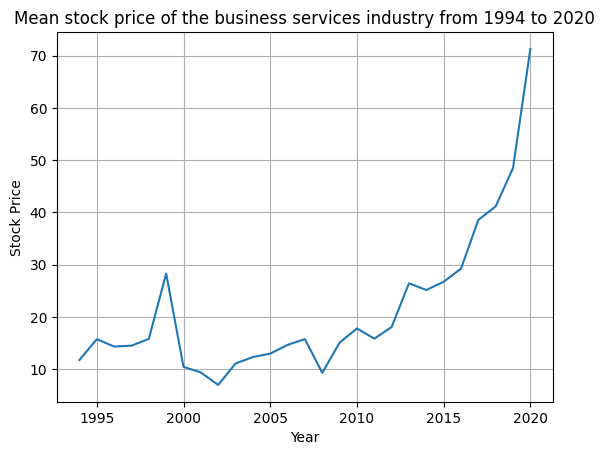

In [18]:
import matplotlib.pyplot as plt

plt.plot(mean_prcc_c_by_year)
plt.grid(True)
plt.title('Mean stock price of the business services industry from 1994 to 2020')
plt.xlabel('Year')
plt.ylabel('Stock Price')

In [19]:
#5
#Perplexity was used to generate the base code below

prices_2007 = df_pf_filtered.loc[df_pf_filtered['fyear'] == 2007, ['conm','prcc_c']].rename(columns={'prcc_c':'prcc_c_2007'})
prices_2008 = df_pf_filtered.loc[df_pf_filtered['fyear'] == 2008, ['conm','prcc_c']].rename(columns={'prcc_c':'prcc_c_2008'})

price_change = prices_2007.merge(prices_2008, on='conm', how='inner')
price_change['percentage_drop'] = (price_change['prcc_c_2007'] - price_change['prcc_c_2008']) / price_change['prcc_c_2007'] * 100

most_affected = price_change.sort_values('percentage_drop', ascending=False).head(1)
most_affected

,conm,prcc_c_2007,prcc_c_2008,percentage_drop
672,ISSUER DIRECT CORP,1.25,0.0071,99.432


In [22]:
#6
df_pf_USA = df_pf_filtered.groupby('location').get_group('USA')
df_pf_USA

,gvkey,fyear,location,conm,ipodate,sic,prcc_c,ch,ni,asset,sale,roa
53,1019,1995,USA,AFA PROTECTIVE SYSTEMS INC,NaN,7380,115.00,4.565,1.339,28.487,27.492,0.047004
54,1019,1996,USA,AFA PROTECTIVE SYSTEMS INC,NaN,7380,117.00,5.293,1.060,28.968,27.160,0.036592
55,1019,1997,USA,AFA PROTECTIVE SYSTEMS INC,NaN,7380,215.00,1.654,1.139,26.710,29.740,0.042643
56,1019,1998,USA,AFA PROTECTIVE SYSTEMS INC,NaN,7380,207.00,1.507,1.647,29.283,34.175,0.056244
57,1019,1999,USA,AFA PROTECTIVE SYSTEMS INC,NaN,7380,206.00,1.187,1.024,29.341,37.272,0.034900
...,...,...,...,...,...,...,...,...,...,...,...,...
208940,298036,2020,USA,STARTEK INC,NaN,7389,7.52,44.507,-38.985,604.653,640.222,-0.064475
209074,316747,2020,USA,GAN LTD,NaN,7370,20.28,152.654,-20.217,173.246,35.159,-0.116695
209200,339965,2018,USA,SNOWFLAKE INC,2020/09/10,7370,NaN,116.541,-178.028,764.288,96.666,-0.232933
209201,339965,2019,USA,SNOWFLAKE INC,2020/09/10,7370,NaN,127.206,-348.535,1012.720,264.748,-0.344157


In [23]:
mean_roa_by_year_USA = df_pf_USA.groupby('fyear')['roa'].mean()
mean_roa_by_year_USA

fyear
1994   -0.124107
1995   -0.143584
1996   -0.185157
1997   -0.382198
1998   -0.542005
1999   -0.370483
2000   -0.768409
2001   -1.147295
2002   -0.603669
2003   -0.676420
2004   -0.513439
2005   -0.391852
2006   -0.413167
2007   -0.538425
2008   -0.799864
2009   -0.561188
2010   -0.288558
2011   -0.446614
2012   -1.371651
2013   -0.988943
2014   -0.646866
2015   -0.602918
2016   -0.711370
2017   -0.840017
2018   -0.563119
2019   -0.214482
2020   -0.416815
Name: roa, dtype: float64

Text(0, 0.5, 'ROA')

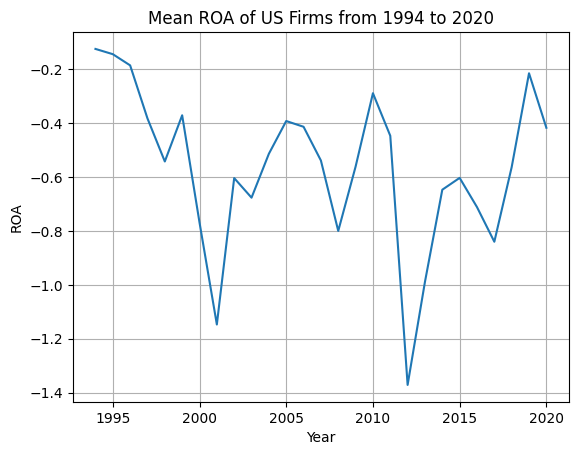

In [24]:
plt.plot(mean_roa_by_year_USA)
plt.grid(True)
plt.title('Mean ROA of US Firms from 1994 to 2020')
plt.xlabel('Year')
plt.ylabel('ROA')

PART 2C

In [25]:

import string
import nltk
from nltk.corpus import stopwords

# Download stopwords 
nltk.download('stopwords')

#  Lowercase
df["cleaned_item_1"] = df["item_1_text"].str.lower()

#Perplexity was used to generate the base code below
# Remove punctuation
df["cleaned_item_1"] = df["cleaned_item_1"].str.replace(f"[{string.punctuation}]", "", regex=True)

#Perplexity was used to generate the base code below
# Remove stopwords 
stop_words = set(stopwords.words("english"))

cleaned = []
for text in df["cleaned_item_1"]:
    words = text.split()
    filtered_words = []
    for w in words:
        if w not in stop_words:     # only keep if not a stopword
            filtered_words.append(w)
    cleaned.append(" ".join(filtered_words))

df["cleaned_item_1"] = cleaned

# Show first few rows
df[["item_1_text", "cleaned_item_1"]].head()

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/shrikarchoudhary/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,item_1_text,cleaned_item_1
0,fixed expenses are previosuly documented in an...,fixed expenses previosuly documented 8k 235000...
1,"General Hurco Companies, Inc. is an internatio...",general hurco companies inc international indu...
2,We have been engaged in the business of develo...,engaged business developing marketing products...
3,CORPORATE HISTORY Chun Can Capital Group (form...,corporate history chun capital group formerly ...
4,CORPORATE HISTORY Chun Can Capital Group (form...,corporate history chun capital group formerly ...


PART D1

In [26]:
import pandas as pd
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [27]:
# Keep only Business Services firms
df_business = public_firm[public_firm["sic"].astype(str).str.startswith("73")].copy()

# Merge using inner join (only Business Services firms will be kept)
df_bs = pd.merge(df, df_business, on="gvkey", how="inner")

print("Number of firms in Business Services sector (With 10k data):", df_bs.shape[0])

Number of firms in Business Services sector (With 10k data): 7372


PART D2

In [28]:
#ChatGPT was used to generate the base code below
#Top Keywords (Word Counts)
def get_top_keywords_wordcount(text, n=10):
    if pd.isnull(text):
        return []
    words = text.split()
    counter = Counter(words)
    return [w for w, _ in counter.most_common(n)]

df_bs["top_keywords_wc"] = df_bs["cleaned_item_1"].apply(get_top_keywords_wordcount)

In [29]:
#ChatGPT was used to generate the base code below
#Top Keywords (TF-IDF)
vectorizer = TfidfVectorizer(max_features=1000, stop_words="english")
X = vectorizer.fit_transform(df_bs["cleaned_item_1"].fillna(""))

feature_names = vectorizer.get_feature_names_out()

top_keywords_tfidf = []
for row in X:
    scores = row.toarray().flatten()
    top_idx = scores.argsort()[-10:][::-1]
    top_terms = [feature_names[i] for i in top_idx if scores[i] > 0]
    top_keywords_tfidf.append(top_terms)

df_bs["top_keywords_tfidf"] = top_keywords_tfidf

In [30]:
print(df_bs[["conm", "top_keywords_wc", "top_keywords_tfidf"]].head())

               conm                                    top_keywords_wc  \
0  ACCESS POWER INC  [2019, company, time, marijuana, work, october...   
1  ACCESS POWER INC  [2019, company, time, marijuana, work, october...   
2  ACCESS POWER INC  [2019, company, time, marijuana, work, october...   
3  ACCESS POWER INC  [2019, company, time, marijuana, work, october...   
4   TRACK GROUP INC  [monitoring, device, tracking, company, produc...   

                                  top_keywords_tfidf  
0  [2019, home, october, company, time, expenses,...  
1  [2019, home, october, company, time, expenses,...  
2  [2019, home, october, company, time, expenses,...  
3  [2019, home, october, company, time, expenses,...  
4  [tracking, monitoring, device, remote, registe...  


PART D3

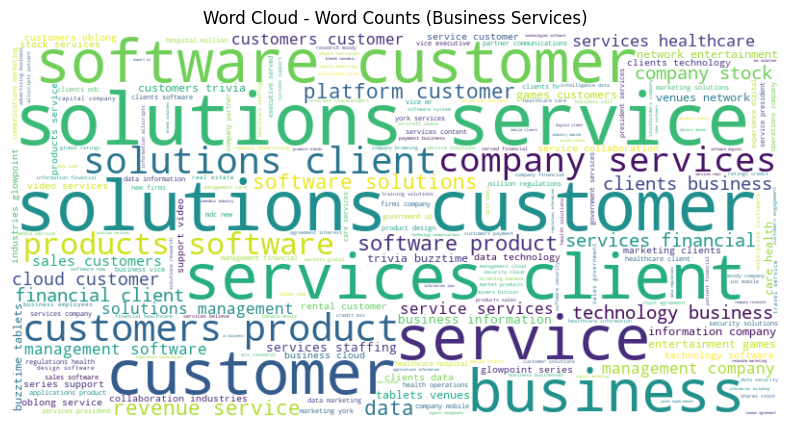

In [31]:
#ChatGPT was used to generate the base code below
# Word Count-based Word Cloud
all_wc_words = " ".join([" ".join(words) for words in df_bs["top_keywords_wc"]])
wordcloud_wc = WordCloud(width=800, height=400, background_color="white").generate(all_wc_words)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud_wc, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud - Word Counts (Business Services)")
plt.show()

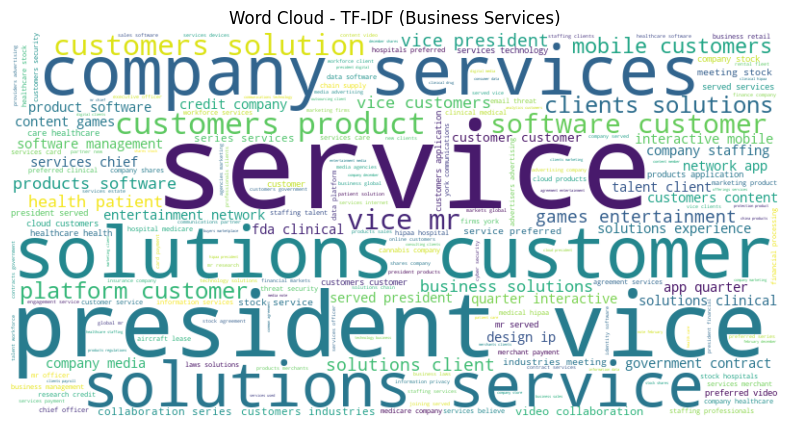

In [32]:
# TF-IDF-based Word Cloud
all_tfidf_words = " ".join([" ".join(words) for words in df_bs["top_keywords_tfidf"]])
wordcloud_tfidf = WordCloud(width=800, height=400, background_color="white").generate(all_tfidf_words)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud_tfidf, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud - TF-IDF (Business Services)")
plt.show()

PART E1

In [33]:
pip install gensim

Note: you may need to restart the kernel to use updated packages.


In [34]:
pip install numpy scipy


Note: you may need to restart the kernel to use updated packages.


In [35]:
import gensim
from gensim.models import Word2Vec

print("Gensim version:", gensim.__version__)


Gensim version: 4.3.3


In [36]:
from gensim.models import Word2Vec

#Tokenize cleaned text
sentences = [text.split() for text in df["cleaned_item_1"].dropna()]

#Train a lighter Word2Vec model, code confirmed from CHATGPT
w2v_model = Word2Vec(
    sentences=sentences,
    vector_size=50,   # smaller embedding size
    window=3,         # smaller context window
    min_count=5,      # ignore words that appear < 5 times
    workers=2,        # fewer CPU threads
    sg=0              # CBOW (faster than skip-gram)
)

print("Word2Vec training finished for Business Services.")


Word2Vec training finished for Business Services.


PART E2

In [37]:
#CHATGPT was used to generate the base code below
#Keywords Word Cloud
keywords = ["solutions", "company", "customer"]

for word in keywords:
    if word in w2v_model.wv:   # check only once
        print(f"\nTop 5 words similar to '{word}':")
        for sim_word, score in w2v_model.wv.most_similar(word, topn=5):
            print(f"  {sim_word} ({score:.3f})")
    else:
        print(f"'{word}' not in vocabulary")




Top 5 words similar to 'solutions':
  capabilities (0.786)
  platforms (0.784)
  solution (0.783)
  endtoend (0.783)
  services (0.735)

Top 5 words similar to 'company':
  business (0.730)
  transaction (0.635)
  acquisition (0.627)
  subsidiaries (0.622)
  operations (0.620)

Top 5 words similar to 'customer':
  client (0.922)
  customers (0.823)
  subscriber (0.747)
  clients (0.747)
  enduser (0.724)


PART 3F

In [38]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
#Perplexity was used to generate the base code below
#Combine WC + TF-IDF keywords and build embedding
def get_combined_firm_embedding(top_keywords_wc, top_keywords_tfidf, w2v_model, vector_size=50):

    #Combine counts and TF-IDF keywords for a firm and generate a single embedding.
    
    combined_keywords = []

    if isinstance(top_keywords_wc, list):
        combined_keywords += top_keywords_wc
    if isinstance(top_keywords_tfidf, list):
        combined_keywords += top_keywords_tfidf

    embedding = np.zeros(vector_size)
    count = 0

    for word in combined_keywords:
        if word in w2v_model.wv:
            embedding += w2v_model.wv[word]
            count += 1

    # Avoid division by zero
    if count > 0:
        embedding /= count

    return embedding

In [57]:
vector_size = w2v_model.vector_size

df_bs['firm_embedding_combined'] = df_bs.apply(
    lambda row: get_combined_firm_embedding(row['top_keywords_wc'], row['top_keywords_tfidf'], w2v_model, vector_size),
    axis=1
)

In [ ]:
#Perplexity was used to generate the base code below
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Pick your focal firm (replace with actual gvkey)
focal_firm_name = 'MICROSOFT CORP'

# Get the embedding of the focal firm
focal_firm_embedding = df_bs.loc[df_bs['name'] == focal_firm_name, 'firm_embedding_combined'].values[0]

# Stack all firm embeddings into a matrix
embeddings_matrix = np.vstack(df_bs['firm_embedding_combined'].values)

# Compute cosine similarity between focal firm and all firms
similarities = cosine_similarity(focal_firm_embedding.reshape(1, -1), embeddings_matrix).flatten()

# Add similarity scores to the DataFrame
df_bs['similarity_to_focal'] = similarities

# Get top 5 most similar firms (excluding the focal firm itself)
similar_firms = df_bs[df_bs['name'] != focal_firm_name].sort_values(by='similarity_to_focal', ascending=False)

print(similar_firms[['name', 'similarity_to_focal']].head(5))

              name  similarity_to_focal
4544  VMWARE, INC.             0.950835
4543  VMWARE, INC.             0.950835
4551  VMWARE, INC.             0.950835
4550  VMWARE, INC.             0.950835
4549  VMWARE, INC.             0.950835


In [59]:
print(similar_firms[['name', 'similarity_to_focal']].drop_duplicates('name').head(5))

                    name  similarity_to_focal
4544        VMWARE, INC.             0.950835
4165   Support.com, Inc.             0.944067
613   CITRIX SYSTEMS INC             0.934996
6274         ORACLE CORP             0.929160
1934   RingCentral, Inc.             0.921635


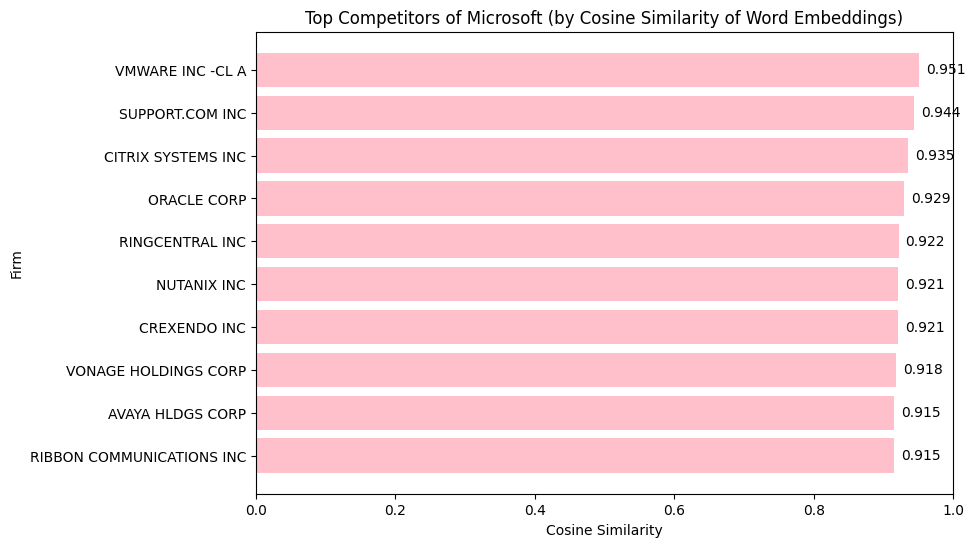

In [88]:
import matplotlib.pyplot as plt

# Select top 10 competitors
top_competitors = (
    similar_firms[['conm', 'similarity_to_focal']]
    .drop_duplicates('conm')
    .head(10)
)
plt.figure(figsize=(9,6))
bars = plt.barh(top_competitors['conm'], top_competitors['similarity_to_focal'], color='pink')
plt.gca().invert_yaxis()
plt.title("Top Competitors of Microsoft (by Cosine Similarity of Word Embeddings)")
plt.xlabel("Cosine Similarity")
plt.xlim(0, 1)   # scale 0 → 1 for consistency
plt.ylabel("Firm")

#Perplexity was used to generate the base code below
# Add similarity values on bars
for bar in bars:
    plt.text(
        bar.get_width() + 0.01,   # a little to the right of bar
        bar.get_y() + bar.get_height()/2,
        f"{bar.get_width():.3f}",
        va ='center'
    )

plt.show()


In [62]:
top_competitor_name = top_competitors.iloc[:][['conm']]

In [100]:
top_competitor_row = df_bs[df_bs["conm"].isin(top_competitor_name["conm"])]

In [64]:
focal_firm_row = df_bs[df_bs['name'] == focal_firm_name]

In [91]:
top_similar_dendrogram_row = pd.concat([top_competitor_row, focal_firm_row])

In [92]:
firm_embeddings_dendrogram_df = pd.DataFrame(
    top_similar_dendrogram_row['firm_embedding_combined'].tolist(),
    index=top_similar_dendrogram_row['gvkey']
)

print(firm_embeddings_dendrogram_df.head())

             0         1         2         3         4         5         6   \
gvkey                                                                         
61676 -3.862824 -0.392412  0.274778  0.542705  0.121657  0.443159  0.443043   
61676 -3.862824 -0.392412  0.274778  0.542705  0.121657  0.443159  0.443043   
61676 -3.862824 -0.392412  0.274778  0.542705  0.121657  0.443159  0.443043   
61676 -3.862824 -0.392412  0.274778  0.542705  0.121657  0.443159  0.443043   
61676 -3.862824 -0.392412  0.274778  0.542705  0.121657  0.443159  0.443043   

             7         8         9   ...        40       41        42  \
gvkey                                ...                                
61676  0.787769  0.380208 -0.263699  ...  0.545968  0.20723  0.215293   
61676  0.787769  0.380208 -0.263699  ...  0.545968  0.20723  0.215293   
61676  0.787769  0.380208 -0.263699  ...  0.545968  0.20723  0.215293   
61676  0.787769  0.380208 -0.263699  ...  0.545968  0.20723  0.215293   
61676  0

In [93]:
#https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.drop_duplicates.html

firm_embeddings_dendrogram_df = firm_embeddings_dendrogram_df.drop_duplicates(keep='first')

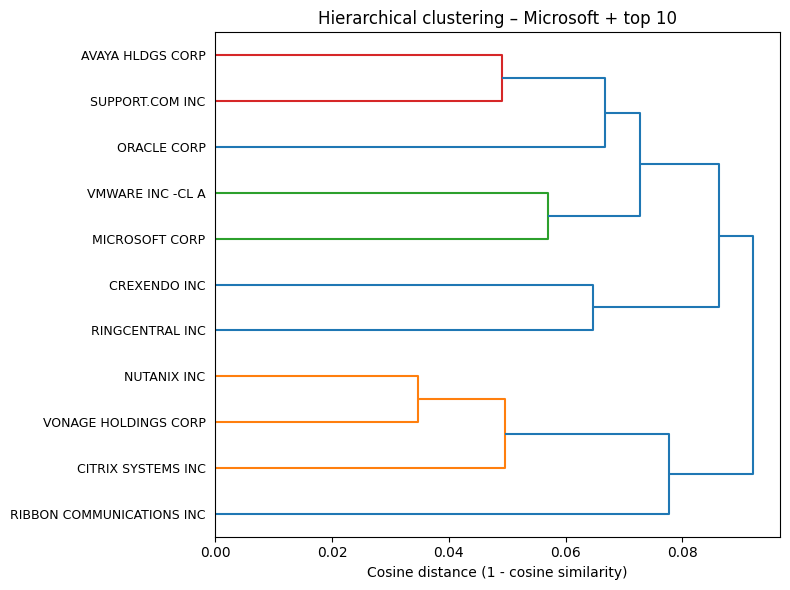

In [98]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram

# Inputs:
# - firm_embeddings: DataFrame indexed by firm name, columns are embedding dims
# - similar_firms: DataFrame with columns ['name','similarity_to_focal'] for Microsoft

focal = "MICROSOFT CORP"
top10 = (top_competitor_row[['conm','similarity_to_focal']]
         .drop_duplicates('conm')
         .head(10)['conm']
         .tolist())
firms = [focal] + top10

X = firm_embeddings_dendrogram_df

# Hierarchical clustering on cosine distance
Z = linkage(X, method='average', metric='cosine')  # try 'complete' if tighter, chain-averse clusters are desired

plt.figure(figsize=(8, 6))
dendrogram(Z, labels=firms, orientation='right', leaf_font_size=9, #Issue is probably because firm_embeddings_similar_df has more than 20 rows.
           color_threshold=0.7 * Z[:, 2].max())
plt.title("Hierarchical clustering – Microsoft + top 10")
plt.xlabel("Cosine distance (1 - cosine similarity)")
plt.tight_layout()
plt.show()


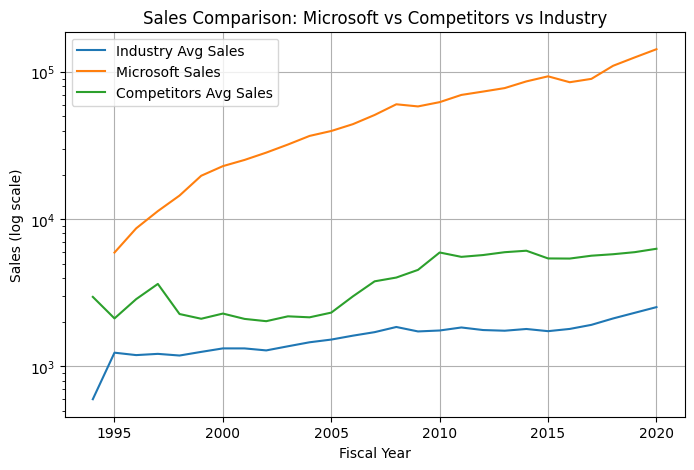

In [69]:
#Sales comparison
mean_sales_focal_firm = focal_firm_row.groupby('fyear')['sale'].mean()
mean_sales_by_year = df_bs.groupby('fyear')['sale'].mean()
mean_sales_top_similar = top_competitor_row.groupby('fyear')['sale'].mean()

plt.figure(figsize=(8,5))
plt.plot(mean_sales_by_year, label="Industry Avg Sales")
plt.plot(mean_sales_focal_firm, label="Microsoft Sales")
plt.plot(mean_sales_top_similar, label="Competitors Avg Sales")
plt.yscale('log')  # log scale for readability
plt.grid(True)
plt.title("Sales Comparison: Microsoft vs Competitors vs Industry")
plt.xlabel("Fiscal Year")
plt.ylabel("Sales (log scale)")
plt.legend(loc="upper left")
plt.show()

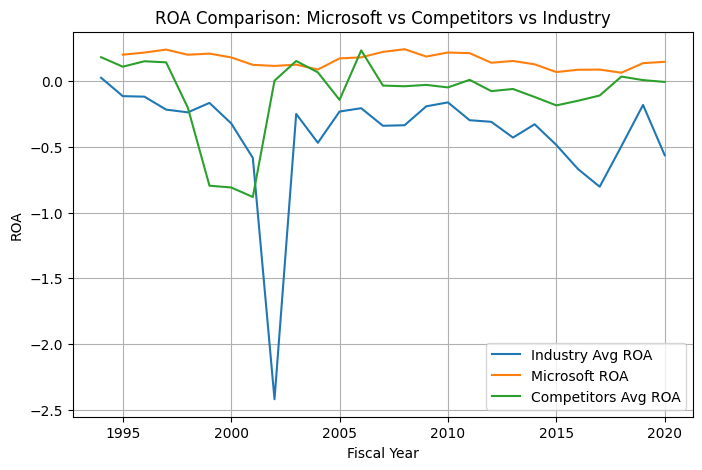

In [70]:
#ROA comparison
mean_roa_focal_firm = focal_firm_row.groupby('fyear')['roa'].mean()
mean_roa_by_year = df_bs.groupby('fyear')['roa'].mean()
mean_roa_top_similar = top_competitor_row.groupby('fyear')['roa'].mean()

plt.figure(figsize=(8,5))
plt.plot(mean_roa_by_year, label="Industry Avg ROA")
plt.plot(mean_roa_focal_firm, label="Microsoft ROA")
plt.plot(mean_roa_top_similar, label="Competitors Avg ROA")
plt.grid(True)
plt.title("ROA Comparison: Microsoft vs Competitors vs Industry")
plt.xlabel("Fiscal Year")
plt.ylabel("ROA")
plt.legend(loc="lower right")
plt.show()